In [1]:
import subprocess
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout if r.returncode == 0 else 'no gpu')


Sun Jun 28 21:05:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:B3:00.0 Off |                    0 |
| N/A   31C    P0             50W /  300W |       0MiB /  39936MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
pip install -q pandas numpy matplotlib psutil tqdm datasets tiktoken

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import sys, json, time, math, shutil, random, socket, platform, subprocess
import datetime as dt
import gc
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output, Image as IPImage

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.use_deterministic_algorithms(True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    GPU_NAME = torch.cuda.get_device_name(0)
else:
    GPU_NAME = "cpu"

PRECISION = "bf16"
AMP_DTYPE = torch.bfloat16 if (PRECISION == "bf16" and DEVICE == "cuda" and torch.cuda.is_bf16_supported()) else torch.float32
USE_AMP = DEVICE == "cuda" and AMP_DTYPE in (torch.float16, torch.bfloat16)

PROJECT_ID = "residual_124m_corrected_v1"
EXP_NAME   = "AttnOnly_std_seed123"
SEED       = 123

REMOTE_ROOT = "gdrive:ResidualInitRuns"
REMOTE_RUN_PATH = f"{REMOTE_ROOT}/{PROJECT_ID}/runs/{EXP_NAME}/"

LOCAL_ROOT = Path("/workspace/residual_gain_runs")
PROJECT_DIR = LOCAL_ROOT / PROJECT_ID
DATA_DIR   = PROJECT_DIR / "data"
RUN_DIR    = PROJECT_DIR / "runs" / EXP_NAME
CKPT_DIR   = RUN_DIR / "checkpoints"
FIG_DIR    = RUN_DIR / "figures"
TABLE_DIR  = RUN_DIR / "tables"
META_DIR   = RUN_DIR / "metadata"
for d in [DATA_DIR, CKPT_DIR, FIG_DIR, TABLE_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

N_LAYER, N_EMBD, N_HEAD, BLOCK_SIZE, DROPOUT = 12, 768, 12, 1024, 0.10
BATCH_SIZE, GRAD_ACCUM = 16, 8
MAX_ITERS, EVAL_INTERVAL, EVAL_BATCHES = 20000, 500, 50
LEARNING_RATE, MIN_LR, WARMUP_ITERS = 6e-4, 6e-5, 2000
WEIGHT_DECAY, BETA1, BETA2, GRAD_CLIP = 0.10, 0.9, 0.95, 1.0
USE_GRAD_CHECKPOINTING = True
OWT_TARGET_DOCS, OWT_VAL_EVERY_N_DOCS = 100_000, 10_000

print(f"{DEVICE} | {GPU_NAME} | torch {torch.__version__} | cuda {torch.version.cuda}")
print(f"{EXP_NAME} seed={SEED}")
print(f"local: {RUN_DIR}")
print(f"drive: {REMOTE_RUN_PATH}")


cuda | NVIDIA A100-SXM4-40GB | torch 2.12.0+cu130 | cuda 13.0
AttnOnly_std_seed123 seed=123
local: /workspace/residual_gain_runs/residual_124m_corrected_v1/runs/AttnOnly_std_seed123
drive: gdrive:ResidualInitRuns/residual_124m_corrected_v1/runs/AttnOnly_std_seed123/


In [4]:
import tiktoken

def load_memmap(path, dtype="uint16"):
    return np.memmap(path, dtype=dtype, mode="r")

DATASET_DIR = DATA_DIR / f"openwebtext_bpe_{BLOCK_SIZE}"
DATASET_DIR.mkdir(parents=True, exist_ok=True)
train_path = DATASET_DIR / "train.bin"
val_path   = DATASET_DIR / "val.bin"

enc = tiktoken.get_encoding("gpt2")
VOCAB_SIZE = enc.n_vocab

if train_path.exists() and val_path.exists():
    print("cached")
else:
    from datasets import load_dataset
    ds = load_dataset("Skylion007/openwebtext", split="train", streaming=True)
    train_buf, val_buf = [], []
    train_count = val_count = 0
    FLUSH_EVERY = 10_000
    for doc in ds:
        tokens = enc.encode_ordinary(doc["text"])
        if train_count % OWT_VAL_EVERY_N_DOCS == 0 and train_count > 0:
            val_buf.extend(tokens); val_count += 1
        else:
            train_buf.extend(tokens); train_count += 1
        if len(train_buf) >= FLUSH_EVERY * 100:
            arr = np.array(train_buf, dtype=np.uint16)
            with open(train_path, "ab") as f: f.write(arr.tobytes())
            train_buf = []
        if len(val_buf) >= FLUSH_EVERY * 10:
            arr = np.array(val_buf, dtype=np.uint16)
            with open(val_path, "ab") as f: f.write(arr.tobytes())
            val_buf = []
        total = train_count + val_count
        if total % 5000 == 0:
            print(total)
        if total >= OWT_TARGET_DOCS:
            break
    if train_buf:
        arr = np.array(train_buf, dtype=np.uint16)
        with open(train_path, "ab") as f: f.write(arr.tobytes())
    if val_buf:
        arr = np.array(val_buf, dtype=np.uint16)
        with open(val_path, "ab") as f: f.write(arr.tobytes())

train_data_mm = load_memmap(str(train_path))
val_data_mm   = load_memmap(str(val_path))
print(f"train {len(train_data_mm)/1e6:.1f}M val {len(val_data_mm)/1e6:.1f}M vocab={VOCAB_SIZE}")


README.md:   0%|          | 0.00/7.46k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

5000
10000
15000
20000
25000
30000
35000
40000
45000
50000
55000
60000
65000
70000
75000
80000
85000
90000
95000
100000
train 11.1M val 101.7M vocab=50257


In [5]:
class SequenceBatcher:
    def __init__(self, train_mm, val_mm, block_size, batch_size, device, seed=1337):
        self.train_mm = train_mm
        self.val_mm = val_mm
        self.block_size = block_size
        self.batch_size = batch_size
        self.device = device
        self.generator = torch.Generator(device="cpu")
        self.generator.manual_seed(seed)
        self.fixed_val_batches = []

    def _offsets(self, length, n):
        hi = max(1, length - self.block_size - 1)
        return torch.randint(0, hi, (n,), generator=self.generator)

    def sample(self, split):
        src = self.train_mm if split == "train" else self.val_mm
        ix = self._offsets(len(src), self.batch_size)
        x = np.stack([src[i:i+self.block_size].astype(np.int64) for i in ix])
        y = np.stack([src[i+1:i+self.block_size+1].astype(np.int64) for i in ix])
        return (torch.from_numpy(x).to(self.device, non_blocking=True),
                torch.from_numpy(y).to(self.device, non_blocking=True))

    def build_fixed_val_batches(self, count):
        old_state = self.generator.get_state()
        self.generator.manual_seed(99991)
        self.fixed_val_batches = [self.sample("val") for _ in range(count)]
        self.generator.set_state(old_state)
        print(f"{len(self.fixed_val_batches)} fixed val batches")

BATCHER = SequenceBatcher(train_data_mm, val_data_mm, BLOCK_SIZE, BATCH_SIZE, DEVICE, seed=1337)
BATCHER.build_fixed_val_batches(EVAL_BATCHES)


50 fixed val batches


In [6]:
@dataclass
class ResidualSwitch:
    use_attention_skip: bool = True
    use_mlp_skip: bool = True

class CausalAttentionLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.qkv = nn.Linear(N_EMBD, 3 * N_EMBD, bias=False)
        self.out = nn.Linear(N_EMBD, N_EMBD, bias=False)
        self.drop = nn.Dropout(DROPOUT)
        self.n_head = N_HEAD
        self.head_dim = N_EMBD // N_HEAD

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, dropout_p=self.drop.p if self.training else 0.0, is_causal=True)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.drop(self.out(y))

class TokenMixerMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.up = nn.Linear(N_EMBD, 4 * N_EMBD, bias=False)
        self.down = nn.Linear(4 * N_EMBD, N_EMBD, bias=False)
        self.drop = nn.Dropout(DROPOUT)
        self.latest_dead_frac = None

    def forward(self, x):
        h = F.gelu(self.up(x))
        if not self.training:
            self.latest_dead_frac = float((h.detach() <= 0).float().mean().cpu())
        return self.drop(self.down(h))

class ResidualBlock(nn.Module):
    def __init__(self, switch: ResidualSwitch):
        super().__init__()
        self.switch = switch
        self.ln1 = nn.LayerNorm(N_EMBD)
        self.ln2 = nn.LayerNorm(N_EMBD)
        self.attn = CausalAttentionLayer()
        self.mlp = TokenMixerMLP()
        self.latest_hidden_norm = None
        self.latest_attn_norm = None
        self.latest_mlp_norm = None

    def forward(self, x):
        a = self.attn(self.ln1(x))
        if not self.training:
            self.latest_attn_norm = float(a.detach().norm(dim=-1).mean().cpu())
        x = x + a if self.switch.use_attention_skip else a
        m = self.mlp(self.ln2(x))
        if not self.training:
            self.latest_mlp_norm = float(m.detach().norm(dim=-1).mean().cpu())
        x = x + m if self.switch.use_mlp_skip else m
        if not self.training:
            self.latest_hidden_norm = float(x.detach().norm(dim=-1).mean().cpu())
        return x

class ResidualGPT(nn.Module):
    def __init__(self, switch: ResidualSwitch):
        super().__init__()
        self.switch = switch
        self.token_embed = nn.Embedding(VOCAB_SIZE, N_EMBD)
        self.pos_embed = nn.Embedding(BLOCK_SIZE, N_EMBD)
        self.drop = nn.Dropout(DROPOUT)
        self.blocks = nn.ModuleList([ResidualBlock(switch) for _ in range(N_LAYER)])
        self.ln_f = nn.LayerNorm(N_EMBD)
        self.lm_head = nn.Linear(N_EMBD, VOCAB_SIZE, bias=False)
        self.lm_head.weight = self.token_embed.weight
        self.apply(self._init_weights)
        scale = 0.02 / math.sqrt(2 * N_LAYER)
        for name, p in self.named_parameters():
            if name.endswith("attn.out.weight") or name.endswith("mlp.down.weight"):
                nn.init.normal_(p, mean=0.0, std=scale)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.token_embed(idx) + self.pos_embed(pos))
        for block in self.blocks:
            if USE_GRAD_CHECKPOINTING and self.training:
                x = torch.utils.checkpoint.checkpoint(block, x, use_reentrant=False)
            else:
                x = block(x)
        logits = self.lm_head(self.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.reshape(-1))
        return logits, loss

    def param_count(self):
        return sum(p.numel() for p in self.parameters())

    def diagnostics(self):
        return {
            "hidden_norm_by_layer": [b.latest_hidden_norm for b in self.blocks],
            "attn_norm_by_layer": [b.latest_attn_norm for b in self.blocks],
            "mlp_norm_by_layer": [b.latest_mlp_norm for b in self.blocks],
            "dead_frac_by_layer": [b.mlp.latest_dead_frac for b in self.blocks],
        }

ATTNONLY_SWITCH = ResidualSwitch(use_attention_skip=True, use_mlp_skip=False)
_test = ResidualGPT(ATTNONLY_SWITCH)
print(f"{_test.param_count()/1e6:.2f}M params")
del _test
if DEVICE == "cuda":
    torch.cuda.empty_cache()


124.36M params


In [7]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if DEVICE == "cuda":
        torch.cuda.manual_seed_all(seed)

def lr_at(step):
    if step < WARMUP_ITERS:
        return LEARNING_RATE * (step + 1) / WARMUP_ITERS
    if step >= MAX_ITERS:
        return MIN_LR
    progress = (step - WARMUP_ITERS) / max(1, MAX_ITERS - WARMUP_ITERS)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return MIN_LR + cosine * (LEARNING_RATE - MIN_LR)

@torch.no_grad()
def eval_loss_and_diag(model):
    model.eval()
    train_losses, val_losses = [], []
    for _ in range(EVAL_BATCHES):
        xb, yb = BATCHER.sample("train")
        _, loss = model(xb, yb)
        train_losses.append(float(loss.detach().cpu()))
    for xb, yb in BATCHER.fixed_val_batches[:EVAL_BATCHES]:
        _, loss = model(xb, yb)
        val_losses.append(float(loss.detach().cpu()))
    diag = model.diagnostics()
    model.train()
    return float(np.mean(train_losses)), float(np.mean(val_losses)), float(math.exp(min(np.mean(val_losses), 20.0))), diag

def make_optimizer(model):
    decay = [p for n, p in model.named_parameters() if p.ndim >= 2]
    no_decay = [p for n, p in model.named_parameters() if p.ndim < 2]
    return torch.optim.AdamW(
        [{"params": decay, "weight_decay": WEIGHT_DECAY},
         {"params": no_decay, "weight_decay": 0.0}],
        lr=LEARNING_RATE, betas=(BETA1, BETA2))


In [8]:
def atomic_save(obj, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp)
    tmp.replace(path)

def atomic_write_text(path, text):
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(text, encoding="utf-8")
    tmp.replace(path)

def save_history(history):
    (TABLE_DIR / "history.jsonl").write_text("\n".join(json.dumps(r) for r in history), encoding="utf-8")
    pd.DataFrame(history).to_csv(TABLE_DIR / "history.csv", index=False)

def load_checkpoint_if_available(model, optimizer):
    ckpt_path = CKPT_DIR / "latest.pt"
    if not ckpt_path.exists():
        return 0, [], float("inf"), -1
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    print(f"resumed step {ckpt['step']} best_val={ckpt['best_val']:.6f}")
    return ckpt["step"], ckpt["history"], ckpt["best_val"], ckpt["best_step"]

def save_checkpoint(model, optimizer, step, history, best_val, best_step, is_best):
    state = {"step": step, "model_state": model.state_dict(), "optimizer_state": optimizer.state_dict(),
             "history": history, "best_val": best_val, "best_step": best_step}
    atomic_save(state, CKPT_DIR / "latest.pt")
    if is_best:
        atomic_save(state, CKPT_DIR / "best.pt")

def sync_to_drive():
    result = subprocess.run(
        ["rclone", "copy", str(RUN_DIR), REMOTE_RUN_PATH, "--transfers", "4"],
        capture_output=True, text=True
    )
    return result.returncode == 0


In [9]:
def make_dashboard(history, out_path, show=True):
    if not history:
        return
    df = pd.DataFrame(history)
    step = int(df["step"].iloc[-1])
    best_val = float(df["val_loss"].min())
    best_idx = int(df["val_loss"].idxmin())

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    ax = axes[0, 0]
    ax.plot(df["step"], df["train_loss"], label="train", color="#2196F3", lw=1.8)
    ax.plot(df["step"], df["val_loss"], label="val", color="#FF9800", lw=1.8)
    ax.scatter([df.loc[best_idx, "step"]], [best_val], color="#F44336", zorder=5, s=80, label=f"best {best_val:.4f}")
    ax.set_title("loss"); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[0, 1]
    ax.plot(df["step"], df["val_ppl"], color="#9C27B0", lw=1.8)
    ax.set_yscale("log"); ax.set_title("val ppl"); ax.grid(alpha=0.3)

    ax = axes[0, 2]
    ax.plot(df["step"], df["lr"], color="#009688", lw=1.8)
    ax.set_title("lr"); ax.grid(alpha=0.3)

    ax = axes[1, 0]
    ax.plot(df["step"], df["val_loss"] - df["train_loss"], color="#607D8B", lw=1.5)
    ax.axhline(0, color="#333", lw=1)
    ax.set_title("val - train gap"); ax.grid(alpha=0.3)

    ax = axes[1, 1]
    latest_diag = history[-1].get("diag", {})
    hidden = latest_diag.get("hidden_norm_by_layer") or []
    if hidden:
        ax.bar(range(len(hidden)), hidden, color="#3F51B5", alpha=0.8)
    ax.set_title(f"hidden norm by layer (step {step})"); ax.grid(alpha=0.3, axis="y")

    ax = axes[1, 2]
    dead = latest_diag.get("dead_frac_by_layer") or []
    if dead:
        ax.bar(range(len(dead)), [d*100 for d in dead], color="#F44336", alpha=0.8)
    ax.set_ylim(0, 100)
    ax.set_title(f"dead neurons % (step {step})"); ax.grid(alpha=0.3, axis="y")

    fig.suptitle(f"{EXP_NAME} | step {step:,}/{MAX_ITERS:,} | best {best_val:.4f}", fontsize=13, fontweight="bold")
    fig.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    if show:
        clear_output(wait=True)
        display(IPImage(filename=str(out_path)))
    plt.close(fig)


In [10]:
set_seed(SEED)
_m = ResidualGPT(ATTNONLY_SWITCH).to(DEVICE)
_o = make_optimizer(_m)
for s in range(1, 301):
    lr = lr_at(s)
    for g in _o.param_groups: g["lr"] = lr
    _o.zero_grad(set_to_none=True)
    for _ in range(GRAD_ACCUM):
        xb, yb = BATCHER.sample("train")
        ctx = torch.autocast(device_type="cuda", dtype=AMP_DTYPE) if USE_AMP else torch.enable_grad()
        with ctx:
            _, loss = _m(xb, yb)
        (loss / GRAD_ACCUM).backward()
    torch.nn.utils.clip_grad_norm_(_m.parameters(), GRAD_CLIP)
    _o.step()
_, val0, _, _ = eval_loss_and_diag(_m)
print(f"sanity val@300: {val0:.4f} (random init ~10.8)")
del _m, _o
if DEVICE == "cuda": torch.cuda.empty_cache()


sanity val@300: 6.8835 (random init ~10.8)


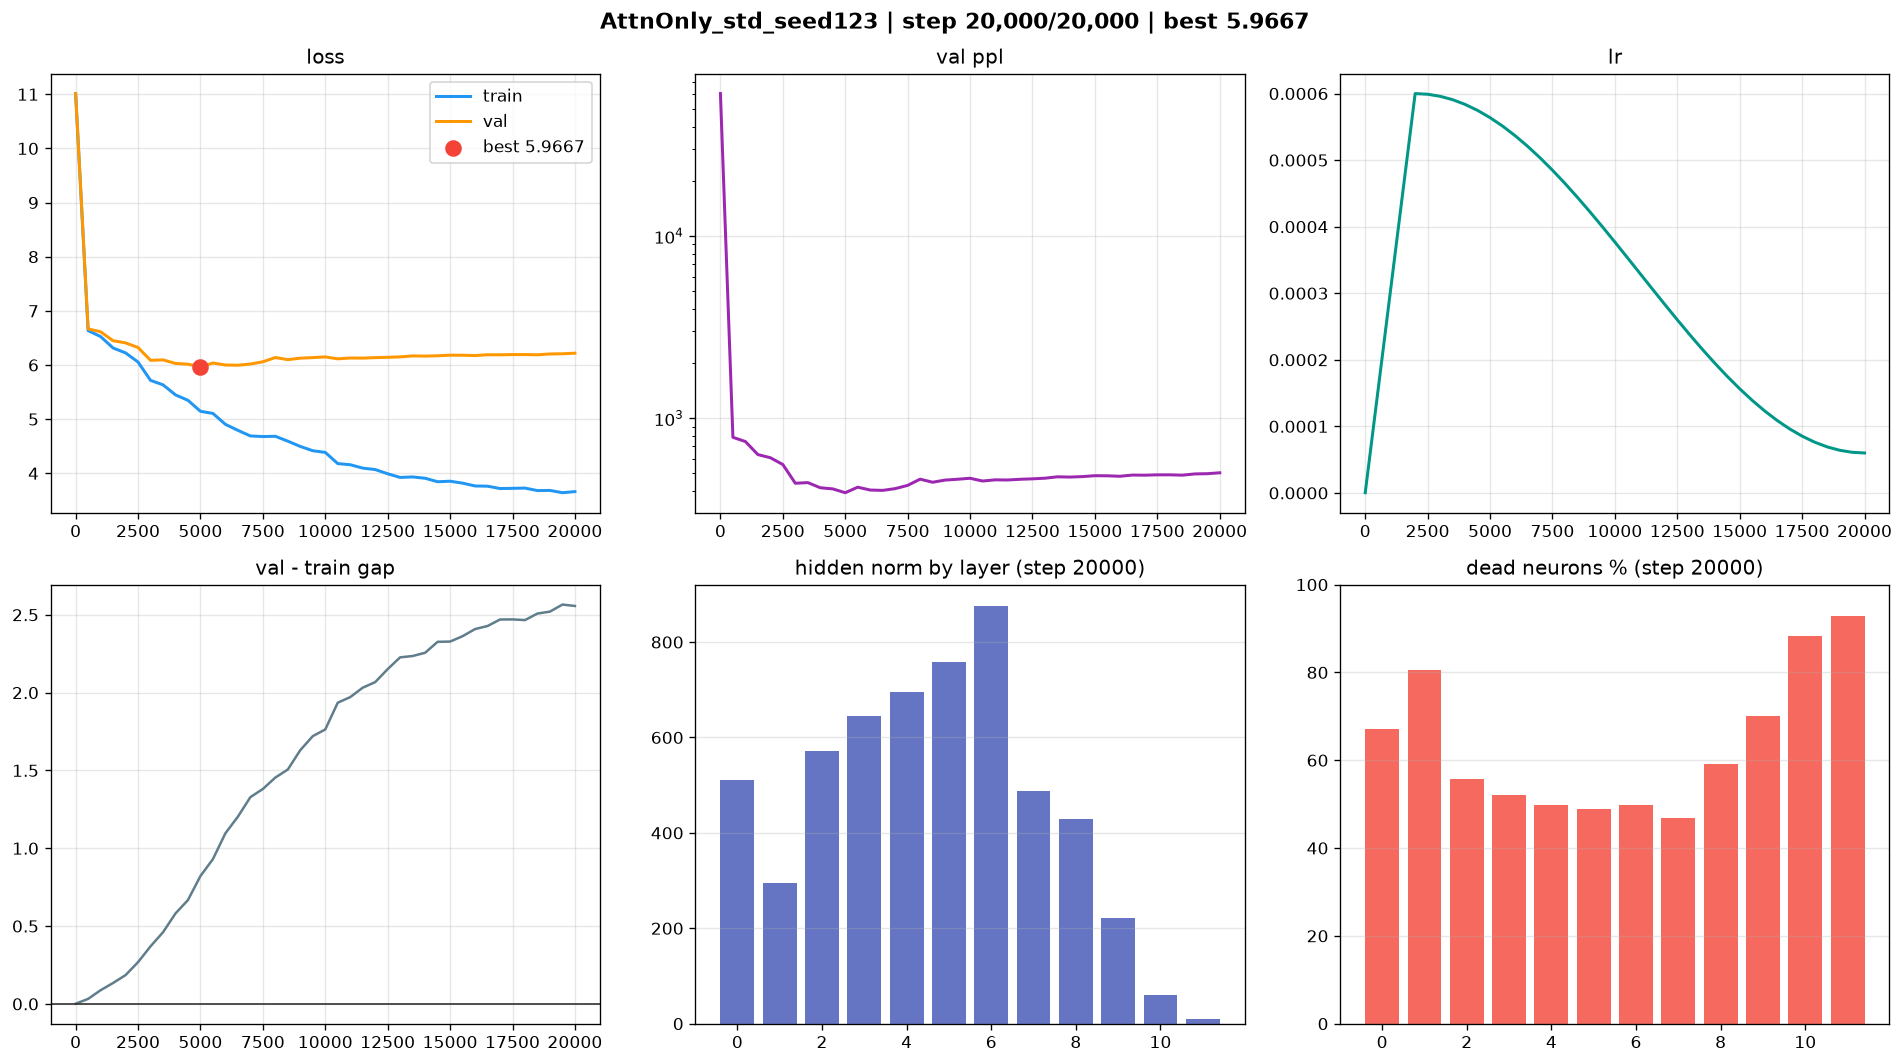

synced to drive: True


done.


In [11]:
set_seed(SEED)
model = ResidualGPT(ATTNONLY_SWITCH).to(DEVICE)
optimizer = make_optimizer(model)
start_step, history, best_val, best_step = load_checkpoint_if_available(model, optimizer)

if start_step == 0 and not history:
    train0, val0, ppl0, diag0 = eval_loss_and_diag(model)
    history.append({"step": 0, "lr": lr_at(0), "train_loss": train0, "val_loss": val0, "val_ppl": ppl0, "diag": diag0})
    best_val, best_step = val0, 0
    save_history(history)
    save_checkpoint(model, optimizer, 0, history, best_val, best_step, is_best=True)
    print(f"step=0 val={val0:.4f}")

model.train()
started = time.time()
HEARTBEAT_EVERY = 25
SYNC_EVERY_EVAL = True

for step in range(start_step + 1, MAX_ITERS + 1):
    lr = lr_at(step)
    for g in optimizer.param_groups: g["lr"] = lr
    optimizer.zero_grad(set_to_none=True)
    last_train_loss = None
    for _ in range(GRAD_ACCUM):
        xb, yb = BATCHER.sample("train")
        ctx = torch.autocast(device_type="cuda", dtype=AMP_DTYPE) if USE_AMP else torch.enable_grad()
        with ctx:
            _, loss = model(xb, yb)
        (loss / GRAD_ACCUM).backward()
        last_train_loss = float(loss.detach().cpu())
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    optimizer.step()

    if step % HEARTBEAT_EVERY == 0:
        elapsed = time.time() - started
        rate = (step - start_step) / max(elapsed, 1e-9)
        eta_min = (MAX_ITERS - step) / max(rate, 1e-9) / 60
        print(f"  step {step:,}/{MAX_ITERS:,} loss={last_train_loss:.4f} {rate:.2f} it/s eta={eta_min:.0f}min", end="\r")

    should_eval = (step % EVAL_INTERVAL == 0) or (step == MAX_ITERS)
    if should_eval:
        train_loss, val_loss, val_ppl, diag = eval_loss_and_diag(model)
        is_best = val_loss < best_val
        if is_best:
            best_val, best_step = val_loss, step
        history.append({"step": step, "lr": lr, "train_loss": train_loss, "val_loss": val_loss, "val_ppl": val_ppl, "diag": diag})
        save_history(history)
        elapsed = time.time() - started
        print(f"\nstep={step:,} train={train_loss:.4f} val={val_loss:.4f} best={best_val:.4f}@{best_step} ({elapsed:.0f}s)")
        save_checkpoint(model, optimizer, step, history, best_val, best_step, is_best=is_best)
        make_dashboard(history, FIG_DIR / "dashboard_latest.png", show=True)
        if SYNC_EVERY_EVAL:
            ok = sync_to_drive()
            print(f"synced to drive: {ok}")

print("\n\ndone.")


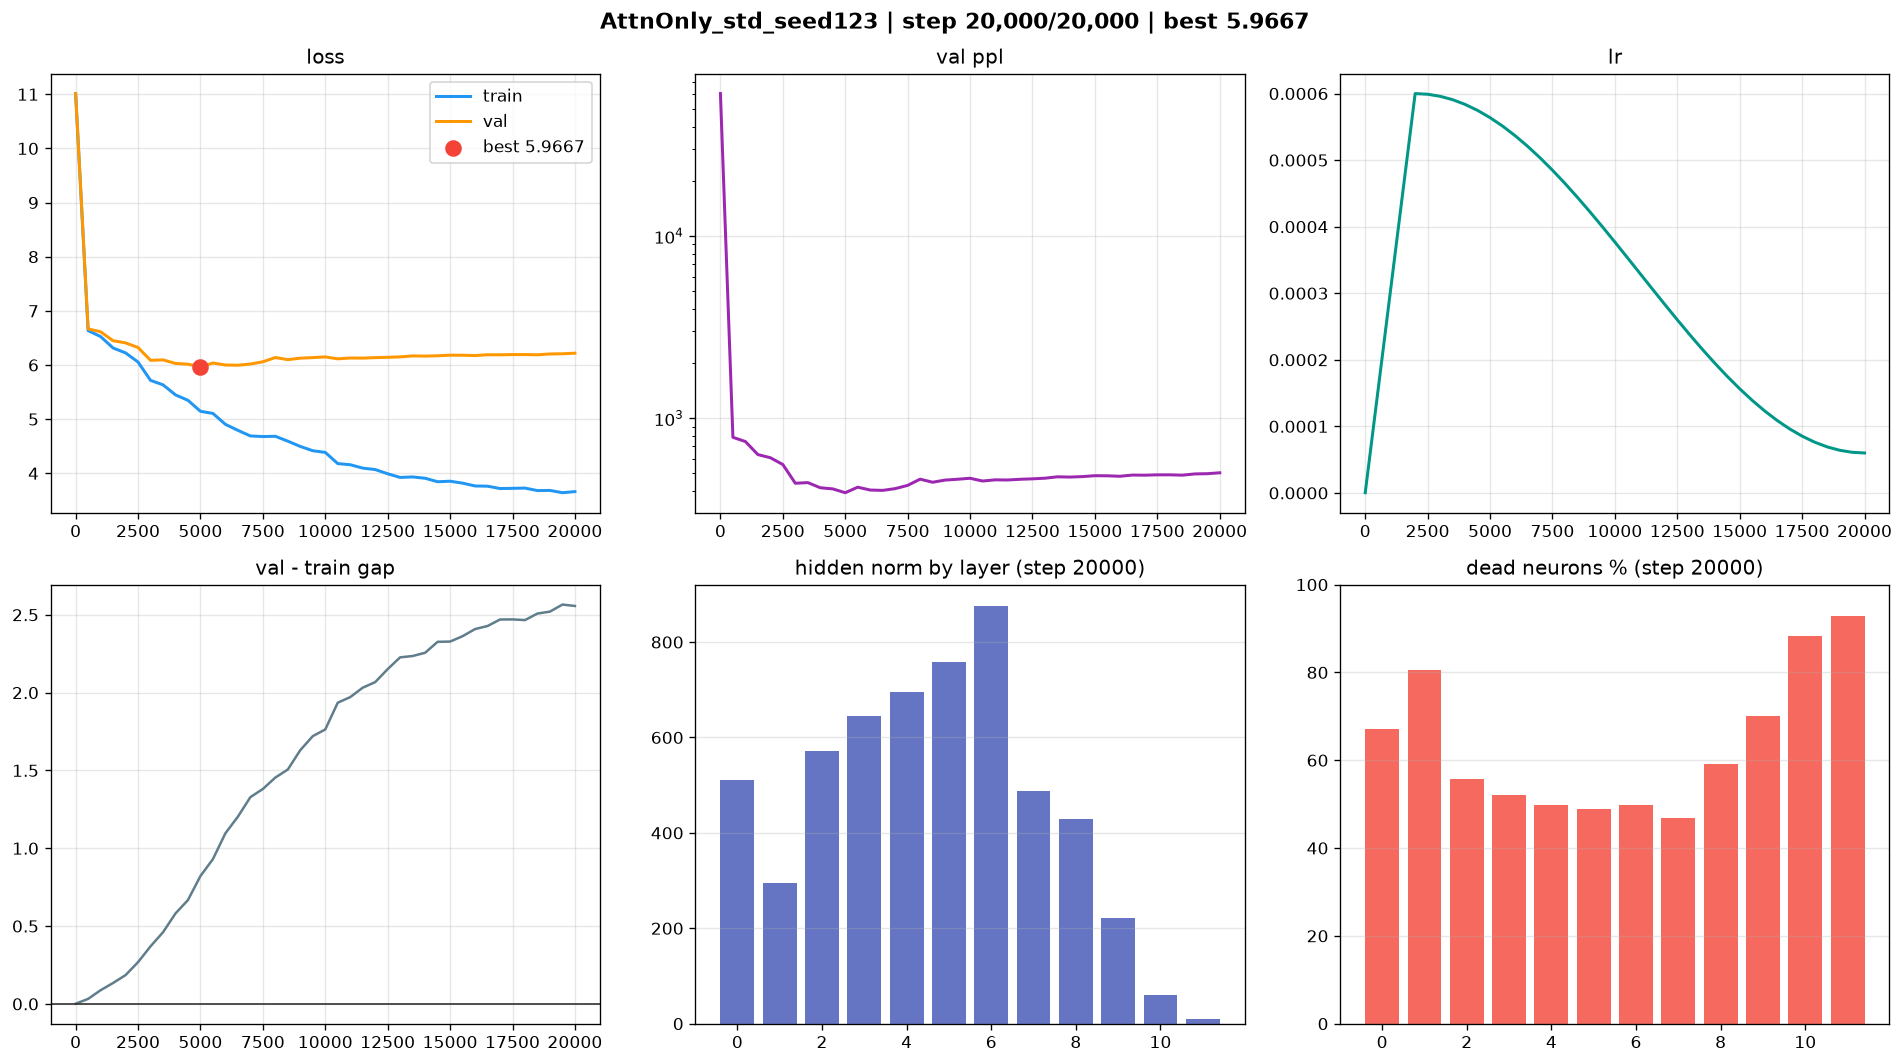

{
  "name": "AttnOnly_std_seed123",
  "seed": 123,
  "use_attention_skip": true,
  "use_mlp_skip": false,
  "best_val_loss": 5.966674757003784,
  "best_step": 5000,
  "final_step": 20000,
  "final_val_loss": 6.218432130813599,
  "num_history_rows": 41,
  "run_dir": "/workspace/residual_gain_runs/residual_124m_corrected_v1/runs/AttnOnly_std_seed123",
  "complete": true
}


In [12]:
summary = {
    "name": EXP_NAME, "seed": SEED, "use_attention_skip": True, "use_mlp_skip": False,
    "best_val_loss": best_val, "best_step": best_step,
    "final_step": history[-1]["step"], "final_val_loss": history[-1]["val_loss"],
    "num_history_rows": len(history), "run_dir": str(RUN_DIR), "complete": True,
}
atomic_write_text(META_DIR / "summary.json", json.dumps(summary, indent=2))
make_dashboard(history, FIG_DIR / "final_dashboard.png", show=True)
sync_to_drive()
print(json.dumps(summary, indent=2))


In [13]:
checks = {
    "latest.pt": CKPT_DIR / "latest.pt",
    "best.pt": CKPT_DIR / "best.pt",
    "history.jsonl": TABLE_DIR / "history.jsonl",
    "history.csv": TABLE_DIR / "history.csv",
    "final_dashboard.png": FIG_DIR / "final_dashboard.png",
    "summary.json": META_DIR / "summary.json",
}
for label, path in checks.items():
    print(f"{label:<20}: {'OK' if path.exists() else 'MISSING'}")

print()
print(f"drive path: {REMOTE_RUN_PATH}")
synced = sync_to_drive()
print(f"final sync: {synced}")


latest.pt           : OK
best.pt             : OK
history.jsonl       : OK
history.csv         : OK
final_dashboard.png : OK
summary.json        : OK

drive path: gdrive:ResidualInitRuns/residual_124m_corrected_v1/runs/AttnOnly_std_seed123/
final sync: True


In [14]:
SEED1337 = 4.8994
SEED42 = 7.5864

print(f"seed 1337: {SEED1337:.4f}")
print(f"seed 42:   {SEED42:.4f}")
print(f"seed 123:  {best_val:.4f}")
print()
vals = [SEED1337, SEED42, best_val]
print(f"mean: {np.mean(vals):.4f}  std: {np.std(vals):.4f}")
print(f"range: {min(vals):.4f} to {max(vals):.4f}")


seed 1337: 4.8994
seed 42:   7.5864
seed 123:  5.9667

mean: 6.1508  std: 1.1047
range: 4.8994 to 7.5864
